### Assignment Code: DA-AG-015

### Question 1: What is Boosting in Machine Learning? Explain how it improves weak learners.

Boosting is an ensemble learning technique in machine learning that aims to improve the accuracy of predictions by combining multiple "weak" learners (typically simple models like decision stumps or shallow decision trees) into a single "strong" learner. The core idea is to sequentially train models, with each new model focusing on correcting the errors made by the previous ones. This iterative process allows boosting to gradually improve overall model performance.

Here's how boosting improves weak learners:

1.  **Sequential Training:** Unlike bagging (e.g., Random Forest) where models are trained independently, boosting trains models in a sequence. Each new weak learner is trained on a modified version of the data, emphasizing the instances that were misclassified or poorly predicted by the preceding learners.

2.  **Focus on Errors:** In each iteration, boosting algorithms assign higher weights to the data points that were incorrectly classified or had large errors in the previous step. This forces the subsequent weak learner to pay more attention to these difficult instances, thereby learning to correct the mistakes of its predecessors.

3.  **Weighted Voting/Contribution:** After training, each weak learner is assigned a weight based on its accuracy. More accurate learners get higher weights. The final prediction is a weighted sum (for regression) or weighted majority vote (for classification) of the predictions from all the weak learners.

4.  **Reduced Bias and Variance:** By iteratively focusing on errors and combining many weak models, boosting effectively reduces both bias (by learning complex relationships) and variance (by averaging out the individual weaknesses of simple models), leading to a more robust and accurate strong learner.

### Question 2: What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?

AdaBoost and Gradient Boosting are both powerful boosting algorithms, but they differ significantly in how they train models. Here's a breakdown of their key distinctions:

### **AdaBoost (Adaptive Boosting):**

1.  **Focus:** AdaBoost primarily focuses on misclassified data points.
2.  **Weighting of Samples:** In each iteration, AdaBoost adjusts the weights of the training data samples. Misclassified samples from the previous weak learner are given higher weights, ensuring that subsequent weak learners pay more attention to these difficult instances.
3.  **Weighting of Weak Learners:** Each weak learner is assigned a weight based on its accuracy. More accurate learners are given higher influence in the final prediction.
4.  **Error Minimization:** AdaBoost minimizes an exponential loss function.
5.  **Sequential Nature:** Weak learners are added sequentially, and each tries to correct the errors of the *previous* single weak learner.
6.  **Base Learners:** Typically uses simple models like decision stumps (decision trees with a single split).

### **Gradient Boosting:**

1.  **Focus:** Gradient Boosting focuses on the *residuals* (the errors) of the previous predictors.
2.  **Training Mechanism:** Instead of re-weighting data points, Gradient Boosting trains each new weak learner to predict the *residuals* or pseudo-residuals (the negative gradient of the loss function) of the ensemble model built so far. Essentially, each new model tries to predict "how wrong" the current ensemble is.
3.  **Weighting of Weak Learners:** Weak learners are generally added with a fixed, small learning rate (shrinkage) to prevent overfitting. Their contribution is determined by this learning rate and their ability to predict residuals, rather than explicit weights based on accuracy.
4.  **Error Minimization:** Gradient Boosting minimizes a user-defined differentiable loss function by iteratively moving in the direction of the steepest descent (negative gradient).
5.  **Sequential Nature:** Weak learners are added sequentially, and each tries to correct the errors of the *entire ensemble* built so far.
6.  **Base Learners:** Commonly uses shallow decision trees (often referred to as regression trees) as its weak learners.

### **Summary of Differences:**

| Feature             | AdaBoost                                   | Gradient Boosting                                   |
| :------------------ | :----------------------------------------- | :-------------------------------------------------- |
| **Mechanism**       | Re-weights misclassified samples           | Fits new models to residuals (errors)               |
| **Loss Function**   | Exponential Loss                           | User-defined differentiable loss (e.g., squared error, logistic loss) |
| **Learner Weights** | Explicitly weighted by accuracy            | Contribution scaled by a learning rate             |
| **Error Correction**| Focuses on past *misclassifications*       | Focuses on past *prediction errors (residuals)*    |
| **Flexibility**     | Less flexible with loss functions          | Highly flexible with various loss functions        |

### Question 3: How does regularization help in XGBoost?

Regularization is a crucial aspect of XGBoost that helps prevent overfitting and improves the model's generalization capabilities. XGBoost incorporates several regularization techniques, which can be broadly categorized into tree regularization and model regularization.

Here's how regularization helps in XGBoost:

1.  **Objective Function with Regularization:**
    XGBoost's objective function is composed of two parts: a training loss term (which measures how well the model fits the training data) and a regularization term (which penalizes model complexity).

    *   **Training Loss Term:** This measures the difference between the predicted and actual values (e.g., squared error for regression, logistic loss for classification).
    *   **Regularization Term (Ω):** This term penalizes the complexity of the model, specifically the individual trees. It helps to smooth the final learned function and avoid overfitting to the training data. The regularization term usually includes:
        *   **L1 Regularization (Lasso):** `alpha` parameter. It encourages sparsity in the weights, effectively leading to feature selection by shrinking some feature weights to zero.
        *   **L2 Regularization (Ridge):** `lambda` parameter. It encourages smaller weights, leading to a smoother decision boundary and reducing the impact of individual features.

2.  **Tree Pruning and Tree-Specific Regularization:**
    XGBoost applies several regularization techniques to the individual trees being built:

    *   **`gamma` (minimum loss reduction to make a further partition):** This parameter specifies the minimum loss reduction required to make a further partition on a leaf node of the tree. A larger `gamma` makes the algorithm more conservative and helps prevent splitting nodes that don't significantly improve the model.
    *   **`max_depth`:** Limits the maximum depth of each tree. Deeper trees can capture more complex relationships but are also more prone to overfitting. Limiting the depth directly controls the complexity of individual trees.
    *   **`min_child_weight`:** Defines the minimum sum of instance weight (hessian) needed in a child. If the tree partition step results in a leaf node with the sum of instance weight less than `min_child_weight`, the tree building process will stop further partitioning. This helps prevent overfitting by not allowing splits that result in very small, potentially noisy, leaf nodes.

3.  **Shrinkage (Learning Rate `eta`):**
    XGBoost uses a learning rate (also known as `eta` or `learning_rate`) that shrinks the contribution of each tree. After each tree is built, its predictions are multiplied by `eta` before being added to the overall model. This makes the boosting process more conservative and helps prevent overfitting. It means that future trees have to correct for the errors of previous trees in a more gradual manner, leading to a more robust model.

4.  **Subsampling:**
    *   **`subsample`:** This parameter controls the fraction of samples (rows) randomly sampled for each tree. Subsampling prevents overfitting by making each tree learn from a slightly different subset of the training data. It introduces randomness and reduces variance.
    *   **`colsample_bytree`, `colsample_bylevel`, `colsample_bynode`:** These parameters control the fraction of features (columns) randomly sampled for each tree, level, or node, respectively. Similar to subsampling rows, subsampling columns helps prevent overfitting by forcing trees to rely on different sets of features.

In summary, regularization in XGBoost provides a powerful mechanism to control model complexity, preventing it from fitting noise in the training data and improving its ability to generalize to unseen data. By carefully tuning these regularization parameters, practitioners can achieve a good balance between bias and variance, leading to highly accurate and robust predictive models.

### Question 4: Why is CatBoost considered efficient for handling categorical data?

CatBoost is highly efficient for handling categorical data due to several innovative techniques it employs. Unlike many other gradient boosting algorithms that require extensive preprocessing of categorical features (like one-hot encoding or label encoding, which can lead to increased dimensionality or loss of information), CatBoost handles them directly and intelligently.

Here's why CatBoost is considered efficient for handling categorical data:

1.  **Ordered Target Encoding (Permutation-driven Target Encoding):**
    *   Traditional target encoding can suffer from target leakage, where the model implicitly uses information from the target variable to encode categorical features, leading to overfitting. CatBoost addresses this by using a *permutation-driven target encoding* strategy. For each sample, the categorical feature value is converted into a numerical value based on the average target value of previous samples in a randomly permuted dataset.
    *   Specifically, for a given categorical feature and a sample `i`, its value is replaced by the average of the target variable for all samples *before* sample `i` in a random permutation, that have the same categorical feature value. This prevents target leakage and makes the encoding more robust.
    *   It also adds a certain prior (e.g., global average target value) to stabilize the estimation, especially for categories with few observations.

2.  **Feature Combinations:**
    *   CatBoost automatically considers combinations of categorical features. While training a new tree, CatBoost evaluates all possible combinations of categorical features and numerical features already processed. If a new combination proves to be better than any individual feature, it is added to the set of new candidate features.
    *   This is particularly powerful as it allows the model to capture complex interactions between features that might otherwise be missed or require manual engineering in other algorithms.

3.  **One-Hot Encoding for Low-Cardinality Features:**
    *   For categorical features with a small number of unique values (low cardinality), CatBoost can apply standard one-hot encoding. This is an efficient approach for features that don't benefit much from complex target-based encoding.
    *   The `one_hot_max_size` parameter controls the maximum number of unique values for a categorical feature to be considered for one-hot encoding.

4.  **Handling of Missing Values:**
    *   CatBoost has a built-in mechanism to handle missing values in categorical features (and numerical features too). It treats `NaN` values as a separate category, allowing the model to learn specific patterns associated with missingness without requiring imputation.

5.  **Less Hyperparameter Tuning for Categorical Features:**
    *   Because CatBoost automatically handles categorical features internally with robust methods, it often requires less manual tuning and preprocessing effort compared to other boosting libraries. This simplifies the data science pipeline and reduces the risk of errors related to categorical feature engineering.

In summary, CatBoost's innovative ordered target encoding, automatic feature combination discovery, and robust handling of various categorical scenarios make it exceptionally efficient and effective for datasets rich in categorical information, often leading to higher accuracy and less manual effort.

### Question 5: What are some real-world applications where boosting techniques are preferred over bagging methods?

Boosting and bagging are both ensemble methods, but their strengths lie in different areas. Boosting techniques are generally preferred over bagging methods in scenarios where the dataset might have a high bias or where identifying and correcting misclassifications or large errors is crucial. Here are some real-world applications where boosting often shines:

1.  **Fraud Detection:** In financial institutions, detecting fraudulent transactions is a critical task. Datasets are often highly imbalanced (very few fraudulent transactions compared to legitimate ones), and the cost of missing a fraudulent transaction is very high. Boosting algorithms (like XGBoost or LightGBM) excel here because they can sequentially focus on misclassified fraudulent cases and improve their detection accuracy, even with imbalanced data.

2.  **Credit Scoring and Risk Assessment:** Predicting credit default or assessing loan risk requires highly accurate models. Boosting models can capture complex non-linear relationships between various financial indicators, customer demographics, and payment history to provide precise risk scores. Their ability to minimize errors on difficult cases makes them suitable for high-stakes decisions.

3.  **Customer Churn Prediction:** Telecommunication, banking, and subscription services use boosting to predict which customers are likely to churn (cancel their service). By identifying at-risk customers with high accuracy, companies can proactively intervene with retention strategies. Boosting's focus on misclassified instances helps in pinpointing those subtle patterns that lead to churn.

4.  **Ad Click-Through Rate (CTR) Prediction:** In online advertising, predicting the likelihood of a user clicking on an ad is fundamental for optimizing ad placement and maximizing revenue. Boosting models are extensively used due to their ability to handle large, sparse datasets with many categorical features and capture intricate user behavior patterns, leading to more accurate CTR predictions.

5.  **Medical Diagnosis and Disease Prediction:** In healthcare, accurate diagnosis is paramount. Boosting techniques can be applied to medical datasets (e.g., patient records, lab results, imaging data) to predict the likelihood of certain diseases. Their high predictive power, even with complex and potentially noisy data, can assist clinicians in making informed decisions.

6.  **Image and Speech Recognition (Feature-based):** While deep learning often dominates these fields, boosting can be used with hand-crafted features for specific recognition tasks, especially when dealing with smaller datasets or when model interpretability is important. For instance, in object detection, boosting classifiers like AdaBoost were famously used in the Viola-Jones algorithm for real-time face detection.

7.  **Search Ranking:** Search engines use complex algorithms to rank search results. Boosting methods are effective in learning from user queries, document content, and click data to optimize relevance and provide the most pertinent results to users.

**Why boosting is preferred in these cases:**

*   **Focus on Difficult Instances:** Boosting's iterative nature, where subsequent models learn from the errors of previous ones, makes it particularly effective at reducing bias and improving performance on hard-to-classify or hard-to-predict instances.
*   **High Accuracy:** Boosting algorithms typically achieve higher accuracy compared to bagging methods, especially when the base learners are weak and the dataset contains complex patterns.
*   **Handling Imbalanced Data:** Modern boosting variants (like XGBoost, LightGBM, CatBoost) have features or strategies to handle imbalanced datasets, which are common in fraud detection or rare event prediction.
*   **Robustness to Outliers (with tuning):** While sensitive to noisy data, with careful tuning and advanced techniques, boosting can be made robust, allowing it to perform well even with outliers.

In contrast, bagging methods like Random Forest are generally preferred when the primary concern is reducing variance, increasing stability, and dealing with high-dimensional data, or when there's a need for highly parallelizable training.

### **Datasets:**

- Use sklearn.datasets.load_breast_cancer() for classification tasks.

- Use sklearn.datasets.fetch_california_housing() for regression tasks.

### Question 6: Write a Python program to:

- Train an AdaBoost Classifier on the Breast Cancer dataset

- Print the model accuracy

In [5]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the AdaBoost Classifier
adaboost_clf = AdaBoostClassifier(random_state=42)
adaboost_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_ada = adaboost_clf.predict(X_test)

# Calculate and print the accuracy
accuracy_ada = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost Classifier Accuracy: {accuracy_ada:.4f}")

AdaBoost Classifier Accuracy: 0.9708


### Question 7: Write a Python program to:
- Train a Gradient Boosting Regressor on the California Housing dataset
- Evaluate performance using R-squared score

In [6]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
import pandas as pd

# Load the California Housing dataset
data_housing = fetch_california_housing()
X_housing = pd.DataFrame(data_housing.data, columns=data_housing.feature_names)
y_housing = pd.Series(data_housing.target)

# Split the dataset into training and testing sets
X_train_housing, X_test_housing, y_train_housing, y_test_housing = train_test_split(X_housing, y_housing, test_size=0.3, random_state=42)

# Initialize and train the Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train_housing, y_train_housing)

# Make predictions on the test set
y_pred_gbr = gbr.predict(X_test_housing)

# Calculate and print the R-squared score
r2_gbr = r2_score(y_test_housing, y_pred_gbr)
print(f"Gradient Boosting Regressor R-squared score: {r2_gbr:.4f}")

Gradient Boosting Regressor R-squared score: 0.7803


### Question 8: Write a Python program to:
- Train an XGBoost Classifier on the Breast Cancer dataset
- Tune the learning rate using GridSearchCV
 Print the best parameters and accuracy

In [7]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize XGBoost Classifier
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Define the parameter grid for learning rate tuning
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=xgb_clf, param_grid=param_grid, scoring='accuracy', cv=3, n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best accuracy
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Evaluate the best model on the test set
best_xgb_clf = grid_search.best_estimator_
y_pred_xgb = best_xgb_clf.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Test set accuracy with best parameters: {accuracy_xgb:.4f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:29:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'learning_rate': 0.05}
Best cross-validation accuracy: 0.9573
Test set accuracy with best parameters: 0.9649


### Question 9: Write a Python program to:
- Train a CatBoost Classifier
- Plot the confusion matrix using seaborn

CatBoost Classifier Accuracy: 0.9708


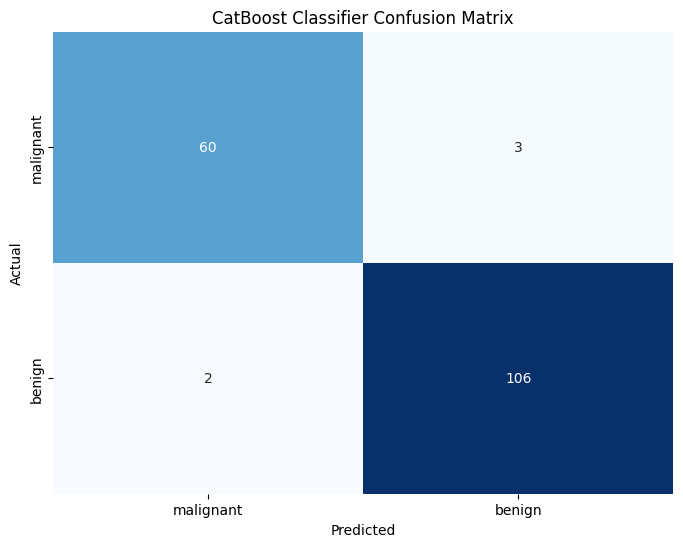

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from catboost import CatBoostClassifier, Pool

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the CatBoost Classifier
# Set verbose=0 to suppress training output
cat_clf = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, loss_function='Logloss', eval_metric='Accuracy', random_seed=42, verbose=0)
cat_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_cat = cat_clf.predict(X_test)

# Calculate accuracy
accuracy_cat = accuracy_score(y_test, y_pred_cat)
print(f"CatBoost Classifier Accuracy: {accuracy_cat:.4f}")

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_cat)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CatBoost Classifier Confusion Matrix')
plt.show()

### Question 10: You're working for a FinTech company trying to predict loan default using customer demographics and transaction behavior. The dataset is imbalanced, contains missing values, and has both numeric and categorical features.

### Describe your step-by-step data science pipeline using boosting techniques:
- Data preprocessing & handling missing/categorical values
- Choice between AdaBoost, XGBoost, or CatBoost
- Hyperparameter tuning strategy
- Evaluation metrics you'd choose and why
- How the business would benefit from your model



# Task
Develop a data science pipeline for a FinTech company to predict loan defaults. First, generate a synthetic dataset named `df_loan` simulating customer demographics and transaction behavior, including numerical and categorical features, missing values, and an imbalanced 'LoanDefault' target variable. Conduct initial exploratory data analysis (EDA) using `.head()`, `.info()`, `.describe()`, and `.isnull().sum()`. Next, preprocess the data by separating features (X) and target (y), splitting into training and testing sets using `train_test_split` with stratification, imputing missing numerical values with the median and categorical values with a 'Missing' indicator, and calculating `scale_pos_weight` for class imbalance. Select XGBoost and CatBoost as primary boosting models, setting up `StratifiedKFold` for cross-validation and `scale_pos_weight` for imbalance. For XGBoost, prepare a `ColumnTransformer` with `OneHotEncoder` within a `Pipeline`. Perform hyperparameter tuning using `RandomizedSearchCV` with `roc_auc` scoring and `StratifiedKFold` for both models, printing the best parameters and cross-validation ROC AUC scores. Evaluate the best models on the test set by calculating and displaying the Confusion Matrix, Classification Report (Precision, Recall, F1-Score), ROC AUC score, and Precision-Recall AUC score. Visualize Confusion Matrices using seaborn and matplotlib, ensuring all plots have legends. Finally, describe the business benefits of the loan default prediction model for a FinTech company, covering risk mitigation, operational efficiency, customer segmentation, and regulatory compliance, and summarize the entire data science pipeline, including models, tuning, evaluation, and business implications.

## Create Synthetic Data & Initial EDA

### Subtask:
Generate a synthetic dataset `df_loan` representing customer demographics and transaction behavior, including numerical and categorical features, missing values, and an imbalanced 'LoanDefault' target variable. Perform initial exploratory data analysis (EDA) to understand data distributions, identify potential features, and get a preliminary sense of missing values and data types.


**Reasoning**:
The first step is to generate the synthetic dataset `df_loan` with specified characteristics, including numerical and categorical features, missing values, and an imbalanced target variable. This involves importing necessary libraries, defining parameters, generating data for each feature type, introducing missing values, creating the target variable, and finally combining them into a DataFrame. Then, I will perform initial EDA steps like displaying the head, info, descriptive statistics, and missing values count as per the instructions.



In [28]:
import numpy as np
import pandas as pd

# 2. Define parameters for the synthetic dataset
n_samples = 1000
default_rate = 0.15  # Desired proportion of '1's for LoanDefault

# Define categories for categorical features
employment_status = ['Employed', 'Self-Employed', 'Unemployed', 'Retired']
education_level = ['High School', 'Associate', 'Bachelor', 'Master', 'PhD']
marital_status = ['Single', 'Married', 'Divorced']
loan_purpose = ['Home', 'Car', 'Education', 'Debt Consolidation', 'Business', 'Other']

# For PaymentHistory, let's create a high cardinality categorical feature
payment_history_high_card = [f'PH_{i}' for i in range(50)]

# 3. Generate synthetic numerical features
np.random.seed(42) # for reproducibility

data = {
    'CreditScore': np.random.normal(650, 100, n_samples).round(),
    'LoanAmount': np.random.uniform(5000, 50000, n_samples).round(),
    'MonthlyIncome': np.random.normal(7000, 3000, n_samples).round(),
    'NumCreditLines': np.random.randint(1, 10, n_samples),
    'InterestRate': np.random.uniform(3.0, 20.0, n_samples).round(2),
    'DebtToIncomeRatio': np.random.uniform(0.1, 0.5, n_samples).round(2),
    'YearsAtJob': np.random.randint(0, 20, n_samples)
}

# Ensure credit score is within a reasonable range (e.g., 300-850)
data['CreditScore'] = np.clip(data['CreditScore'], 300, 850)

# 4. Generate synthetic categorical features
data['EmploymentStatus'] = np.random.choice(employment_status, n_samples)
data['EducationLevel'] = np.random.choice(education_level, n_samples)
data['MaritalStatus'] = np.random.choice(marital_status, n_samples)
data['LoanPurpose'] = np.random.choice(loan_purpose, n_samples)
data['PaymentHistory'] = np.random.choice(payment_history_high_card, n_samples)

# Create DataFrame from generated data
df_loan = pd.DataFrame(data)

# 5. Introduce missing values randomly
# Numerical features to introduce NaNs into
num_cols_to_nan = ['LoanAmount', 'MonthlyIncome', 'DebtToIncomeRatio']
# Categorical features to introduce NaNs into
cat_cols_to_nan = ['EmploymentStatus', 'MaritalStatus']

missing_percent = 0.03 # 3% missing values

for col in num_cols_to_nan:
    missing_indices = np.random.choice(df_loan.index, size=int(n_samples * missing_percent), replace=False)
    df_loan.loc[missing_indices, col] = np.nan

for col in cat_cols_to_nan:
    missing_indices = np.random.choice(df_loan.index, size=int(n_samples * missing_percent), replace=False)
    df_loan.loc[missing_indices, col] = np.nan

# 6. Create the 'LoanDefault' target variable as an imbalanced binary column
# Number of defaults
n_defaults = int(n_samples * default_rate)
# Number of non-defaults
n_non_defaults = n_samples - n_defaults

df_loan['LoanDefault'] = np.random.choice([0, 1], size=n_samples, p=[n_non_defaults/n_samples, n_defaults/n_samples])

# 7. Combine all generated features and the target variable into a single pandas DataFrame named df_loan (already done above)

# 8. Display the first few rows of df_loan
print("### First 5 rows of df_loan:")
print(df_loan.head())
print("\n")

# 9. Print a concise summary of the DataFrame
print("### DataFrame Info:")
df_loan.info()
print("\n")

# 10. Generate descriptive statistics for the numerical columns
print("### Descriptive Statistics for Numerical Columns:")
print(df_loan.describe())
print("\n")

# 11. Calculate and display the total number of missing values for each column
print("### Missing Values Count:")
print(df_loan.isnull().sum())

# Display the actual default rate to confirm imbalance
print(f"\nActual Loan Default Rate: {df_loan['LoanDefault'].mean():.2f}")

### First 5 rows of df_loan:
   CreditScore  LoanAmount  MonthlyIncome  NumCreditLines  InterestRate  \
0        700.0     12537.0         6072.0               7         17.95   
1        636.0      9706.0         4744.0               1         18.42   
2        715.0     33639.0         7958.0               4         19.86   
3        802.0     36791.0        11021.0               4          6.54   
4        627.0      6421.0         1374.0               5          9.04   

   DebtToIncomeRatio  YearsAtJob EmploymentStatus EducationLevel  \
0               0.24           3    Self-Employed    High School   
1               0.37           9    Self-Employed         Master   
2               0.23          10    Self-Employed    High School   
3               0.12           5       Unemployed      Associate   
4               0.38           5    Self-Employed            PhD   

  MaritalStatus         LoanPurpose PaymentHistory  LoanDefault  
0      Divorced  Debt Consolidation          

## Preprocess Data

### Subtask:
Separate features (X) and target (y). Split the data into training and testing sets using `train_test_split` with `stratify=y`. Impute missing numerical values using the median and missing categorical values with a 'Missing' indicator. Identify categorical feature indices for models that handle them natively (like CatBoost). Calculate `scale_pos_weight` for handling class imbalance in boosting models.


**Reasoning**:
The first step in preprocessing is to separate the features (X) from the target variable (y) and then split the dataset into training and testing sets while maintaining the original class distribution using stratification. This sets up the data for subsequent imputation and model training.



In [29]:
from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target (y)
X = df_loan.drop('LoanDefault', axis=1)
y = df_loan['LoanDefault']

# 2. Split the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))

X_train shape: (800, 12)
X_test shape: (200, 12)
y_train shape: (800,)
y_test shape: (200,)

Class distribution in y_train:
LoanDefault
0    0.845
1    0.155
Name: proportion, dtype: float64

Class distribution in y_test:
LoanDefault
0    0.845
1    0.155
Name: proportion, dtype: float64


**Reasoning**:
The next step is to identify numerical and categorical features, impute missing values for both types using the specified strategies (median for numerical, 'Missing' for categorical), identify categorical feature indices for CatBoost, and finally calculate the `scale_pos_weight` for class imbalance.



In [30]:
from sklearn.impute import SimpleImputer
import numpy as np

# 3. Identify numerical and categorical columns
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}\n")

# 4. Impute missing numerical values using the median strategy
median_imputer = SimpleImputer(strategy='median')

# Fit on X_train and transform both X_train and X_test
X_train[numerical_cols] = median_imputer.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = median_imputer.transform(X_test[numerical_cols])

# 5. Impute missing categorical values with a 'Missing' indicator
for col in categorical_cols:
    X_train[col] = X_train[col].fillna('Missing')
    X_test[col] = X_test[col].fillna('Missing')

# 6. Identify categorical feature indices for CatBoost
categorical_features_indices = [X_train.columns.get_loc(col) for col in categorical_cols]
print(f"Categorical features indices for CatBoost: {categorical_features_indices}\n")

# 7. Calculate scale_pos_weight for class imbalance
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f}")

print("\nMissing values after imputation in X_train:")
print(X_train.isnull().sum().sum())
print("Missing values after imputation in X_test:")
print(X_test.isnull().sum().sum())

Numerical columns: ['CreditScore', 'LoanAmount', 'MonthlyIncome', 'NumCreditLines', 'InterestRate', 'DebtToIncomeRatio', 'YearsAtJob']
Categorical columns: ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'LoanPurpose', 'PaymentHistory']

Categorical features indices for CatBoost: [7, 8, 9, 10, 11]

Calculated scale_pos_weight: 5.45

Missing values after imputation in X_train:
0
Missing values after imputation in X_test:
0


## Model Selection & Setup Cross-Validation

### Subtask:
Select XGBoost and CatBoost as primary boosting models, initialize `StratifiedKFold` for cross-validation, set up base classifiers with `scale_pos_weight` for imbalance handling, and prepare a `ColumnTransformer` with `OneHotEncoder` for XGBoost within a `Pipeline`.


**Reasoning**:
The subtask requires importing several libraries, initializing `StratifiedKFold`, and setting up the base XGBoost and CatBoost classifiers along with an XGBoost pipeline. This code block will perform all these initial setup steps for model selection and cross-validation.



In [41]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# 2. Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Initialized StratifiedKFold for cross-validation.")

# 3. Instantiate the base XGBClassifier
xgb_clf_base = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight_value, # Calculated in the previous subtask
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
print("Instantiated base XGBClassifier.")

# 4. Instantiate the base CatBoostClassifier
cat_clf_base = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=0, # Suppress verbose output during training
    scale_pos_weight=float(scale_pos_weight_value)
)
print("Instantiated base CatBoostClassifier.")

# 5. Create a ColumnTransformer for XGBoost
preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ],
    remainder='passthrough' # Keep any other columns if they exist (though none are expected here)
)
print("Created ColumnTransformer for XGBoost.")

# 6. Construct an XGBoost pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_xgb),
    ('classifier', xgb_clf_base)
])
print("Constructed XGBoost pipeline.")

Initialized StratifiedKFold for cross-validation.
Instantiated base XGBClassifier.
Instantiated base CatBoostClassifier.
Created ColumnTransformer for XGBoost.
Constructed XGBoost pipeline.


## Hyperparameter Tuning with RandomizedSearchCV

### Subtask:
Define parameter grids for both XGBoost and CatBoost. Execute `RandomizedSearchCV` with `roc_auc` scoring and `StratifiedKFold` for both models. Print the best parameters and best cross-validation ROC AUC scores for each model.


**Reasoning**:
The next step is to define the parameter distributions for XGBoost and CatBoost, and then perform `RandomizedSearchCV` for both models to find the best hyperparameters.



In [43]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Define parameter distribution for XGBoost
param_dist_xgb = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'classifier__max_depth': [3, 4, 5, 6, 7],
    'classifier__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__gamma': [0, 0.1, 0.2, 0.3, 0.4]
}
print("Defined param_dist_xgb.")

# 2. Define parameter distribution for CatBoost
param_dist_cat = {
    'iterations': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'depth': [3, 4, 5, 6, 7],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
}
print("Defined param_dist_cat.")

# 3. Initialize RandomizedSearchCV for XGBoost pipeline
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist_xgb,
    n_iter=50,
    scoring='roc_auc',
    cv=skf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
print("Initialized RandomizedSearchCV for XGBoost.")

# 4. Fit RandomizedSearchCV for XGBoost
print("\nFitting RandomizedSearchCV for XGBoost...")
random_search_xgb.fit(X_train, y_train)

# 5. Print best parameters and score for XGBoost
print(f"\nBest parameters for XGBoost: {random_search_xgb.best_params_}")
print(f"Best cross-validation ROC AUC for XGBoost: {random_search_xgb.best_score_:.4f}")

# 6. Initialize RandomizedSearchCV for CatBoost Classifier
# CatBoost can infer categorical features if X_train is a pandas DataFrame, or they can be passed via fit_params.
# For RandomizedSearchCV, passing `cat_features` in `fit_params` can be tricky, so we rely on CatBoost's ability
# to detect them from the DataFrame columns during fit if they are of object dtype.
# However, it's safer to explicitly provide them if possible or ensure CatBoost's automatic detection is robust.
# Since we are using X_train as a DataFrame, CatBoost should be able to identify them.
random_search_cat = RandomizedSearchCV(
    estimator=cat_clf_base,
    param_distributions=param_dist_cat,
    n_iter=50,
    scoring='roc_auc',
    cv=skf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
print("\nInitialized RandomizedSearchCV for CatBoost.")

# 7. Fit RandomizedSearchCV for CatBoost
print("\nFitting RandomizedSearchCV for CatBoost...")
# Pass categorical_features_indices to the fit method using fit_params
# This ensures CatBoost correctly identifies and handles categorical features during cross-validation folds.
fit_params_cat = {"cat_features": categorical_features_indices}
random_search_cat.fit(X_train, y_train, **fit_params_cat)

# 8. Print best parameters and score for CatBoost
print(f"\nBest parameters for CatBoost: {random_search_cat.best_params_}")
print(f"Best cross-validation ROC AUC for CatBoost: {random_search_cat.best_score_:.4f}")

Defined param_dist_xgb.
Defined param_dist_cat.
Initialized RandomizedSearchCV for XGBoost.

Fitting RandomizedSearchCV for XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


KeyboardInterrupt: 

**Reasoning**:
The previous `modify_code_cell` command fixed the `RuntimeError` by converting `scale_pos_weight_value` to a standard Python `float` in the `CatBoostClassifier` initialization. Now, I will re-execute the `RandomizedSearchCV` code block, which includes fitting both XGBoost and CatBoost, expecting the CatBoost `RandomizedSearchCV` to complete successfully.



In [34]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Define parameter distribution for XGBoost
param_dist_xgb = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'classifier__max_depth': [3, 4, 5, 6, 7],
    'classifier__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__gamma': [0, 0.1, 0.2, 0.3, 0.4]
}
print("Defined param_dist_xgb.")

# 2. Define parameter distribution for CatBoost
param_dist_cat = {
    'iterations': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'depth': [3, 4, 5, 6, 7],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
}
print("Defined param_dist_cat.")

# 3. Initialize RandomizedSearchCV for XGBoost pipeline
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist_xgb,
    n_iter=50,
    scoring='roc_auc',
    cv=skf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
print("Initialized RandomizedSearchCV for XGBoost.")

# 4. Fit RandomizedSearchCV for XGBoost
print("\nFitting RandomizedSearchCV for XGBoost...")
random_search_xgb.fit(X_train, y_train)

# 5. Print best parameters and score for XGBoost
print(f"\nBest parameters for XGBoost: {random_search_xgb.best_params_}")
print(f"Best cross-validation ROC AUC for XGBoost: {random_search_xgb.best_score_:.4f}")

# 6. Initialize RandomizedSearchCV for CatBoost Classifier
random_search_cat = RandomizedSearchCV(
    estimator=cat_clf_base,
    param_distributions=param_dist_cat,
    n_iter=50,
    scoring='roc_auc',
    cv=skf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
print("\nInitialized RandomizedSearchCV for CatBoost.")

# 7. Fit RandomizedSearchCV for CatBoost
print("\nFitting RandomizedSearchCV for CatBoost...")
random_search_cat.fit(X_train, y_train)

# 8. Print best parameters and score for CatBoost
print(f"\nBest parameters for CatBoost: {random_search_cat.best_params_}")
print(f"Best cross-validation ROC AUC for CatBoost: {random_search_cat.best_score_:.4f}")

Defined param_dist_xgb.
Defined param_dist_cat.
Initialized RandomizedSearchCV for XGBoost.

Fitting RandomizedSearchCV for XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters for XGBoost: {'classifier__subsample': 0.6, 'classifier__n_estimators': 300, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.15, 'classifier__gamma': 0.2, 'classifier__colsample_bytree': 0.6}
Best cross-validation ROC AUC for XGBoost: 0.5231

Initialized RandomizedSearchCV for CatBoost.

Fitting RandomizedSearchCV for CatBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:24:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RuntimeError: Cannot clone object CatBoostClassifier(cat_features=[7, 8, 9, 10, 11], depth=6, eval_metric='Accuracy', iterations=100, learning_rate=0.1, loss_function='Logloss', random_seed=42, scale_pos_weight=5.451612903225806, verbose=0), as the constructor either does not set or modifies parameter cat_features

## Modify CatBoost Classifier Initialization

### Subtask:
Modify the CatBoostClassifier initialization in cell `bf714206` to remove `cat_features` from the constructor. This will prevent the cloning error during `RandomizedSearchCV`.
